Usando dispositivo: cuda

========== INICIANDO BÚSQUEDA PSO ==========
Iter  1/15 | Mejor costo: 0.600769 | Pos: LR=0.03808, Mom=0.961
Iter  2/15 | Mejor costo: 0.600769 | Pos: LR=0.03808, Mom=0.961
Iter  3/15 | Mejor costo: 0.600769 | Pos: LR=0.03808, Mom=0.961
Iter  4/15 | Mejor costo: 0.600769 | Pos: LR=0.03808, Mom=0.961
Iter  5/15 | Mejor costo: 0.600769 | Pos: LR=0.03808, Mom=0.961
Iter  6/15 | Mejor costo: 0.600769 | Pos: LR=0.03808, Mom=0.961
Iter  7/15 | Mejor costo: 0.600769 | Pos: LR=0.03808, Mom=0.961
Iter  8/15 | Mejor costo: 0.600769 | Pos: LR=0.03808, Mom=0.961
Iter  9/15 | Mejor costo: 0.600769 | Pos: LR=0.03808, Mom=0.961
Iter 10/15 | Mejor costo: 0.600769 | Pos: LR=0.03808, Mom=0.961
Iter 11/15 | Mejor costo: 0.600769 | Pos: LR=0.03808, Mom=0.961
Iter 12/15 | Mejor costo: 0.600769 | Pos: LR=0.03808, Mom=0.961
Iter 13/15 | Mejor costo: 0.600769 | Pos: LR=0.03808, Mom=0.961
Iter 14/15 | Mejor costo: 0.599733 | Pos: LR=0.05751, Mom=0.960
Iter 15/15 | Mejor costo: 0.59973

2026-05-01 16:20:34,663 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-01 16:20:34,675 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


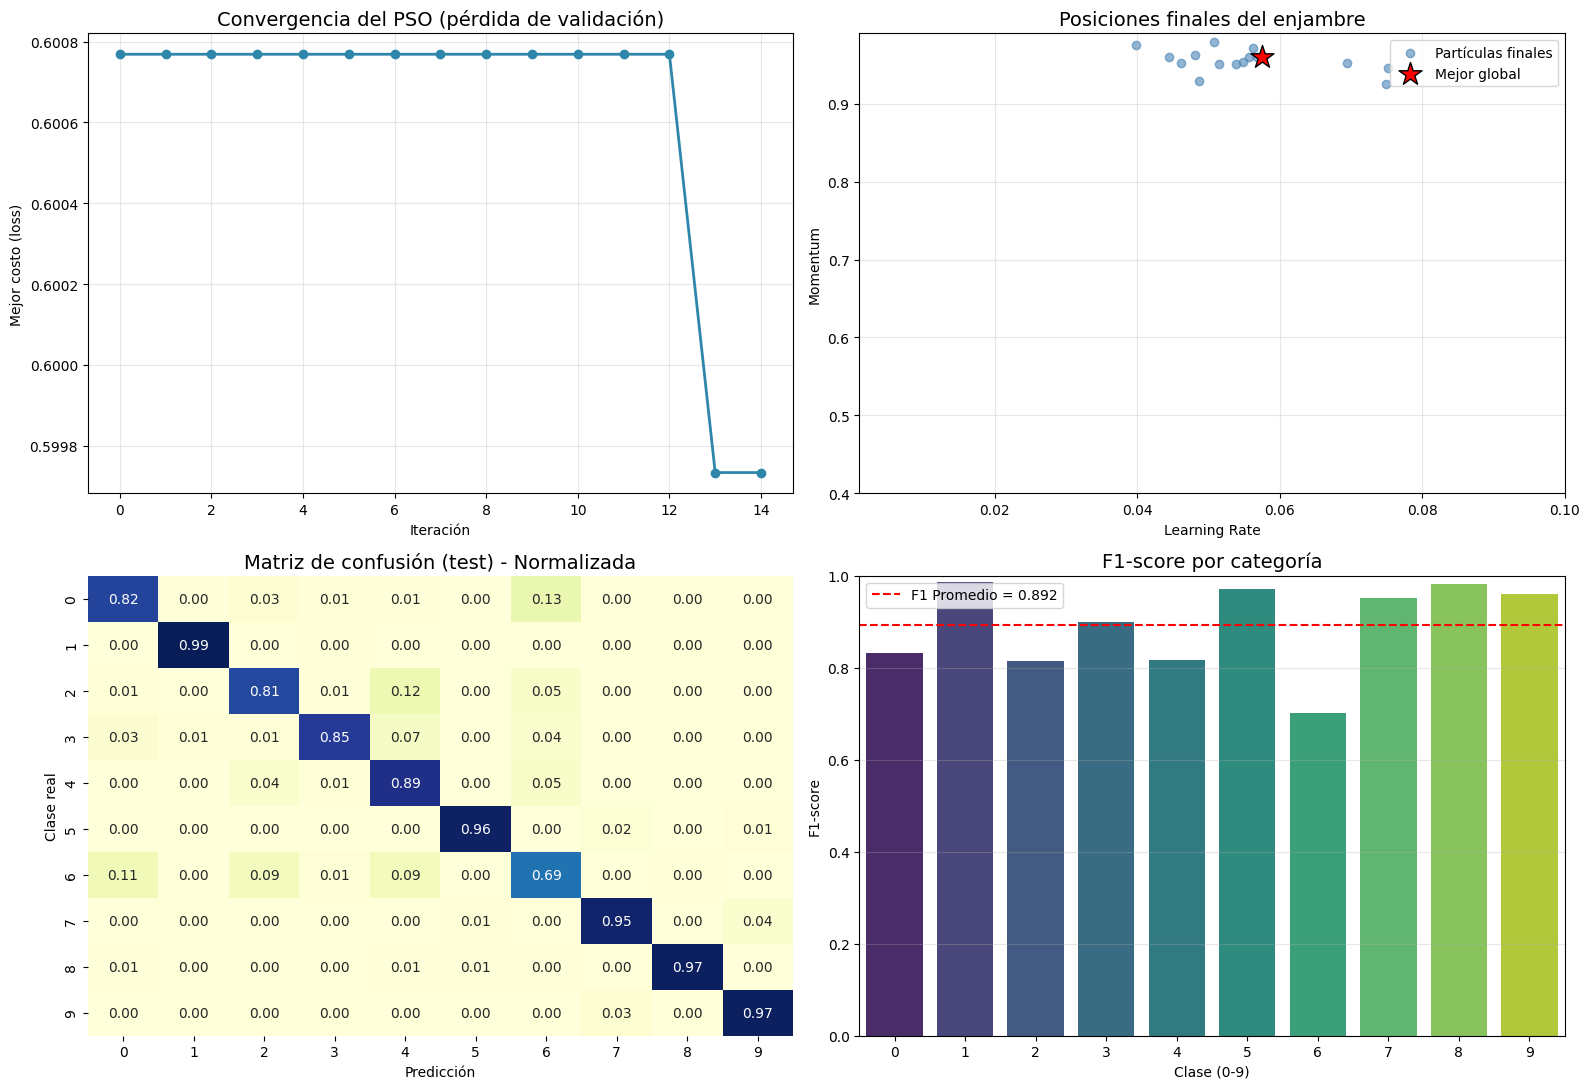


REPORTE FINAL DEL MODELO OPTIMIZADO CON PSO
              precision    recall  f1-score   support

           0     0.8429    0.8210    0.8318      1000
           1     0.9822    0.9910    0.9866      1000
           2     0.8224    0.8060    0.8141      1000
           3     0.9550    0.8480    0.8983      1000
           4     0.7547    0.8920    0.8176      1000
           5     0.9787    0.9640    0.9713      1000
           6     0.7103    0.6940    0.7021      1000
           7     0.9510    0.9500    0.9505      1000
           8     0.9918    0.9730    0.9823      1000
           9     0.9493    0.9730    0.9610      1000

    accuracy                         0.8912     10000
   macro avg     0.8938    0.8912    0.8916     10000
weighted avg     0.8938    0.8912    0.8916     10000

Precisión global: 0.8912


In [ ]:
# ====================================================================
# PSO PARA TUNING DE HIPERPARÁMETROS (CNN EN FASHION-MNIST)
# VERSIÓN CORREGIDA - RUTAS ORIGINALES
# ====================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Dataset, random_split
from sklearn.metrics import confusion_matrix, classification_report
import os
import warnings
warnings.filterwarnings('ignore')

# -------------------- 1. REPRODUCIBILIDAD ---------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

# -------------------- 2. DISPOSITIVO --------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# -------------------- 3. DATASET Y DATA LOADERS (RUTAS ORIGINALES) ---
class FashionCSVDataset(Dataset):
    def __init__(self, csv_file):
        if not os.path.exists(csv_file):
            raise FileNotFoundError(f"No se encontró el archivo: {csv_file}")
        data = pd.read_csv(csv_file)
        self.labels = torch.tensor(data.iloc[:, 0].values, dtype=torch.long)
        self.images = torch.tensor(data.iloc[:, 1:].values, dtype=torch.float32).reshape(-1, 1, 28, 28) / 255.0
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

# === Rutas originales (sin cambiar) ===
train_csv = '/content/sample_data/data/fashion-mnist_train.csv'
test_csv  = '/content/sample_data/data/fashion-mnist_test.csv'

# Carga completa
dataset_full = FashionCSVDataset(train_csv)
test_dataset = FashionCSVDataset(test_csv)

# Subconjuntos para búsqueda PSO (rápido) y validación independiente
train_size = 5000
val_size   = 1000
train_subset, val_subset, _ = random_split(dataset_full, [train_size, val_size, len(dataset_full)-train_size-val_size])
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_subset,   batch_size=64, shuffle=False)

# Para entrenamiento final usamos el dataset completo
final_train_loader = DataLoader(dataset_full, batch_size=128, shuffle=True)
final_test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)

# -------------------- 4. ARQUITECTURA CNN ---------------------------
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128), nn.ReLU(inplace=True),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# -------------------- 5. FUNCIÓN DE APTITUD (FITNESS) ----------------
def evaluate_hyperparams(lr, momentum, num_epochs=1, verbose=False):
    """Entrena 1 época y devuelve pérdida de validación."""
    model = SimpleCNN().to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for _ in range(num_epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            loss = criterion(model(images), labels)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)
    if verbose:
        print(f"LR={lr:.5f}, Mom={momentum:.3f} -> Val Loss={avg_val_loss:.4f}")
    return avg_val_loss

# -------------------- 6. IMPLEMENTACIÓN MANUAL DEL PSO --------------
class ParticleSwarmOptimizer:
    def __init__(self, n_particles, bounds, options, cost_func):
        self.n_particles = n_particles
        self.low, self.high = bounds
        self.dim = len(self.low)
        self.c1 = options['c1']
        self.c2 = options['c2']
        self.w = options['w']
        self.cost_func = cost_func

        self.positions = np.random.uniform(self.low, self.high, (n_particles, self.dim))
        self.velocities = np.zeros((n_particles, self.dim))
        self.personal_best_pos = self.positions.copy()
        self.personal_best_cost = np.full(n_particles, np.inf)
        self.global_best_pos = None
        self.global_best_cost = np.inf
        self.cost_history = []

    def optimize(self, iters, verbose=True):
        for t in range(iters):
            costs = np.array([self.cost_func(p[0], p[1]) for p in self.positions])

            improved = costs < self.personal_best_cost
            self.personal_best_pos[improved] = self.positions[improved]
            self.personal_best_cost[improved] = costs[improved]

            current_best_idx = np.argmin(costs)
            if costs[current_best_idx] < self.global_best_cost:
                self.global_best_cost = costs[current_best_idx]
                self.global_best_pos = self.positions[current_best_idx].copy()

            self.cost_history.append(self.global_best_cost)
            if verbose:
                print(f"Iter {t+1:2d}/{iters} | Mejor costo: {self.global_best_cost:.6f} | "
                      f"Pos: LR={self.global_best_pos[0]:.5f}, Mom={self.global_best_pos[1]:.3f}")

            r1 = np.random.rand(self.n_particles, self.dim)
            r2 = np.random.rand(self.n_particles, self.dim)
            cognitive = self.c1 * r1 * (self.personal_best_pos - self.positions)
            social = self.c2 * r2 * (self.global_best_pos - self.positions)
            self.velocities = self.w * self.velocities + cognitive + social
            self.positions += self.velocities
            self.positions = np.clip(self.positions, self.low, self.high)

        return self.global_best_pos, self.global_best_cost

# -------------------- 7. EJECUCIÓN DEL PSO (CORREGIDA) --------------
bounds_low = np.array([0.001, 0.4])
bounds_high = np.array([0.1, 0.99])
bounds = (bounds_low, bounds_high)
options = {'c1': 1.5, 'c2': 1.5, 'w': 0.7}

pso = ParticleSwarmOptimizer(n_particles=15, bounds=bounds, options=options, cost_func=evaluate_hyperparams)

print("\n========== INICIANDO BÚSQUEDA PSO ==========")
best_params, best_cost = pso.optimize(iters=15, verbose=True)   # ← ahora correcto
best_lr, best_mom = best_params                                 # ← desempaquetado escalares
print(f"\n>>> MEJORES HIPERPARÁMETROS ENCONTRADOS:")
print(f"    Learning Rate = {best_lr:.6f}")
print(f"    Momentum      = {best_mom:.6f}")
print(f"    Pérdida de validación mínima = {best_cost:.4f}")

# -------------------- 8. ENTRENAMIENTO FINAL ------------------------
print("\n========== ENTRENAMIENTO FINAL (10 épocas, dataset completo) ==========")
final_model = SimpleCNN().to(device)
final_optimizer = optim.SGD(final_model.parameters(), lr=best_lr, momentum=best_mom)
criterion = nn.CrossEntropyLoss()

for epoch in range(10):
    running_loss = 0.0
    for images, labels in final_train_loader:
        images, labels = images.to(device), labels.to(device)
        final_optimizer.zero_grad()
        loss = criterion(final_model(images), labels)
        loss.backward()
        final_optimizer.step()
        running_loss += loss.item()
    print(f"Época {epoch+1:2d}/10 | Loss: {running_loss/len(final_train_loader):.4f}")

# -------------------- 9. EVALUACIÓN SOBRE TEST ----------------------
final_model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in final_test_loader:
        images = images.to(device)
        outputs = final_model(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

# -------------------- 10. VISUALIZACIÓN DE RESULTADOS ----------------
plt.figure(figsize=(16, 11))

plt.subplot(2, 2, 1)
plt.plot(pso.cost_history, 'o-', color='#2E86AB', linewidth=2, markersize=6)
plt.title("Convergencia del PSO (pérdida de validación)", fontsize=14)
plt.xlabel("Iteración"); plt.ylabel("Mejor costo (loss)"); plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.scatter(pso.positions[:, 0], pso.positions[:, 1], c='steelblue', alpha=0.6, label='Partículas finales')
plt.scatter(best_lr, best_mom, c='red', marker='*', s=300, edgecolors='black', label='Mejor global')
plt.title("Posiciones finales del enjambre", fontsize=14)
plt.xlabel("Learning Rate"); plt.ylabel("Momentum")
plt.xlim(bounds_low[0], bounds_high[0]); plt.ylim(bounds_low[1], bounds_high[1])
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
cm = confusion_matrix(y_true, y_pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='YlGnBu', cbar=False)
plt.title("Matriz de confusión (test) - Normalizada", fontsize=14)
plt.ylabel("Clase real"); plt.xlabel("Predicción")

plt.subplot(2, 2, 4)
report = classification_report(y_true, y_pred, output_dict=True)
f1_scores = [report[str(i)]['f1-score'] for i in range(10)]
sns.barplot(x=range(10), y=f1_scores, palette='viridis')
plt.axhline(y=np.mean(f1_scores), color='red', linestyle='--', label=f'F1 Promedio = {np.mean(f1_scores):.3f}')
plt.title("F1-score por categoría", fontsize=14)
plt.xlabel("Clase (0-9)"); plt.ylabel("F1-score"); plt.ylim(0, 1); plt.legend(); plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("REPORTE FINAL DEL MODELO OPTIMIZADO CON PSO")
print("="*60)
print(classification_report(y_true, y_pred, digits=4))
print(f"Precisión global: {np.mean(np.array(y_true) == np.array(y_pred)):.4f}")